   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
      

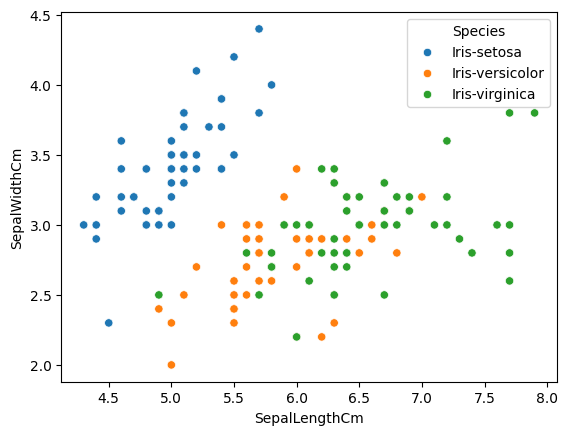

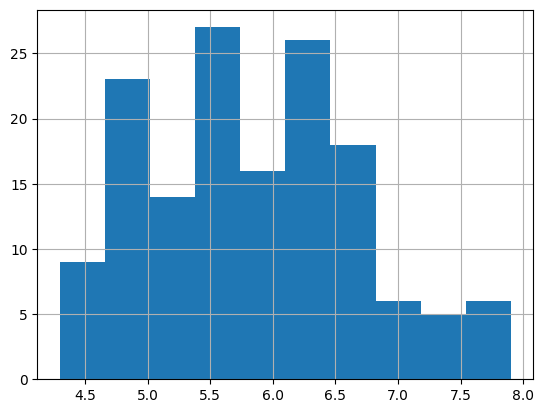

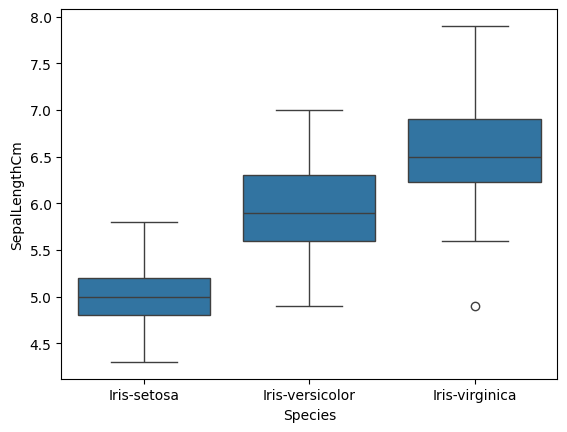

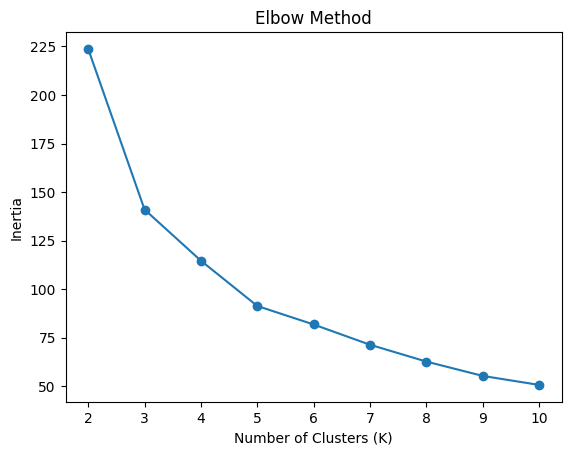

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Documents/Iris.csv")

# EDA
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

print(df['Species'].value_counts())

df_cleaned = df.dropna()

# Scatter Plot
sns.scatterplot(
    data=df_cleaned,
    x='SepalLengthCm',
    y='SepalWidthCm',
    hue='Species'
)
plt.show()

# Histogram
df_cleaned['SepalLengthCm'].hist()
plt.show()

# Box Plot
sns.boxplot(
    data=df_cleaned,
    x='Species',
    y='SepalLengthCm'
)
plt.show()

# Prepare data for K-Means
X = df_cleaned.drop(['Species', 'Id'], axis=1)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means with different K values
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Elbow Graph
plt.plot(k_values, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()